In [1]:
# 1. Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Cài đặt thư viện facenet-pytorch
!pip install facenet-pytorch torchvision Pillow

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 137.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

# Hàm xoay ảnh khi thấy ảnh bị lật ngang

In [1]:
def load_fix_and_rotate(path):
    """Đọc ảnh, tự động xoay EXIF và bỏ qua nếu file lỗi"""
    try:
        img = Image.open(path)
        img = ImageOps.exif_transpose(img) # Tự động xoay đúng chiều
        return img.convert('RGB')
    except:
        return None

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import requests
from io import BytesIO
from facenet_pytorch import MTCNN, InceptionResnetV1

BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/CS231_Dataset_Final'
TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VAL_DIR = os.path.join(BASE_PATH, 'val')
TEST_DIR = os.path.join(BASE_PATH, 'test')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng: {device}")

Đang sử dụng: cuda:0


# 1. Khởi tạo mtcnn
### image_size = 160: Kích thước khuôn mặt sau khi bị cắt ra, mô hình facenet phía sau y/c là ảnh vuông kích thước 160x160 ==> set sẵn để mtcnn tự động resize cho khớp
### margin = 0: Khoảng lề cộng thêm xung quanh khuôn mặt sau khi cắt( ảnh cắt ra bám sát khuôn mặt, không lấy thêm tóc/ cổ/ bối cảnh xung quanh)
### min_face_resize = 20: Kích thước khuôn mặt nhỏ nhất(pixel) mà mtcnn cố gắng tìm kiếm. Ví dụ như set min_face càng nhỏ thì tìm đc người đứng càng xa, nhưng đánh đổi thời gian tính toán.
### ngưỡng = [0.6, 0.7, 0.7]:
#### Mạng 1(P-Net): Quét nhanh toàn bộ gương mặt. Thresh > 60% thì đi tiếp
#### Mạng 2(R Net) Tương tự với mức 0.7
#### Mangk 3(O-Net) Tương tự
### factor = 0.709: Con số tạo tháp ảnh. 0.709 là chuẩn tối ưu được công bố trong bài báo khoa học gốc mtcnn
### post_process = True: MTCNN Tự động chuẩn hóa các pixel ảnh đc cắt. Thay vì dùng dải màu từ 0-255, nó quy đổi về -1 -> 1 để tương thích facenet
# 2. Khởi tạo FaceNet
### Nvụ: Nhận output là 160x160 của mtcnn đưa qua mạng neuron sâu để biến thành 1 vector 512 chiều. Vector này đóng vai trò như căn cước của bức ảnh đó
### InceptionResNetV1: Inception + Resnet(quét nhiều đặc trưng cùng lúc + mạng phần dư)
### pretrained = vggface2: Dùng lại weight của mô hình có sẵn vggface2. Dùng pretrain để mô hình phân biệt khuôn mặt mà không cần học lại từ đầu. Tuy nhiên ở phiên bản việt này ta sẽ dùng bộ tạ 'casia-webface' phù hợp với người Châu Á
### eval(): Đặt mô hình pytorch vào trạng thái suy luận(Chỉ dự đoán)

# Khởi tạo mtcnn

In [3]:
mtcnn = MTCNN(
    image_size=160, margin=0, min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=True,
    device=device
)

# Khởi tạo FaceNet

In [4]:
resnet = InceptionResnetV1(pretrained='casia-webface').eval().to(device)

  0%|          | 0.00/111M [00:00<?, ?B/s]

# Trực quan hóa

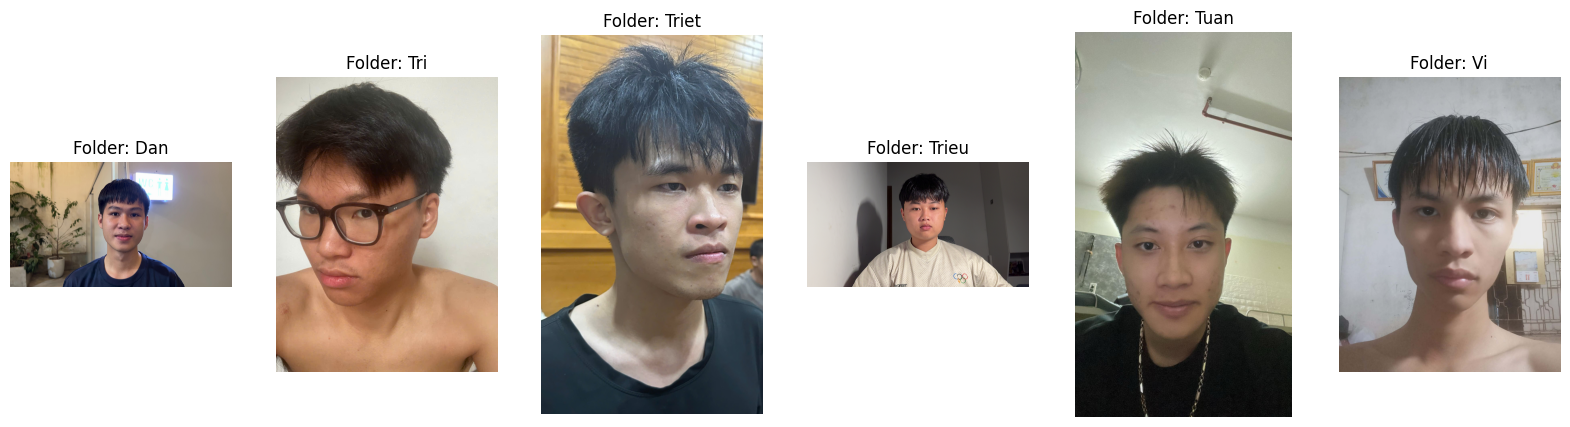

In [8]:
def visualize_dataset(directory, index=0, exclude_folder='trong'):
    if not os.path.exists(directory):
        print(f"Không tìm thấy thư mục: {directory}")
        return
    folders = sorted([f for f in os.listdir(directory)
                      if os.path.isdir(os.path.join(directory, f))
                      and f.lower() not in ['trong', 'trọng']])

    fig, axes = plt.subplots(1, len(folders), figsize=(20, 5))

    if len(folders) == 1: axes = [axes]

    for idx, folder in enumerate(folders):
        folder_path = os.path.join(directory, folder)
        images = sorted([img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])

        found = False
        if index < len(images):
            img_path = os.path.join(folder_path, images[index])
            img = load_fix_and_rotate(img_path)
            if img:
                axes[idx].imshow(img)
                axes[idx].set_title(f"Folder: {folder}")
                found = True

        if not found:
            axes[idx].text(0.5, 0.5, 'who tf is this', ha='center', va='center')
            axes[idx].set_title(f"{folder} (NULL)")

        axes[idx].axis('off')
    plt.show()
visualize_dataset(TRAIN_DIR, index=0)

# Trích xuất đặc trưng

In [9]:
def train_and_save_embeddings(train_path, save_name='face.pt'):
    database = {}
    folders = sorted([f for f in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, f))])

    for folder in folders:
        folder_path = os.path.join(train_path, folder)
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        embs = []

        for img_name in images:
            img = load_fix_and_rotate(os.path.join(folder_path, img_name))
            if img:
                face = mtcnn(img)
                if face is not None:
                    emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()
                    embs.append(emb)

        if embs:
            database[folder] = torch.mean(torch.stack(embs), dim=0)
            print(f"  + Hoàn tất: {folder} ({len(embs)} ảnh)")

    save_path = f'/content/drive/MyDrive/{save_name}'
    torch.save(database, save_path)
    print(f" Đã lưu file face.pt tại: {save_path}")
    return database

# Chạy huấn luyện
face_db = train_and_save_embeddings(TRAIN_DIR)

  + Hoàn tất: Dan (70 ảnh)
  + Hoàn tất: Tri (70 ảnh)
  + Hoàn tất: Triet (70 ảnh)
  + Hoàn tất: Trieu (70 ảnh)
  + Hoàn tất: Tuan (70 ảnh)
  + Hoàn tất: Vi (70 ảnh)
 Đã lưu file face.pt tại: /content/drive/MyDrive/face.pt


# test trên val

In [35]:
def tune_threshold_on_val(val_path, database):
    print("="*70)
    print("ĐÁNH GIÁ TẬP VALIDATION (TÌM NGƯỠNG L2 TỐI ƯU)")
    print("="*70)

    thresholds = np.arange(0.5, 1.3, 0.05)
    best_t = 0.90
    max_acc = 0

    folders = sorted([f for f in os.listdir(val_path) if os.path.isdir(os.path.join(val_path, f))])

    # Cache lại các embedding trong tập Val để chạy cho nhanh
    val_data = []
    for folder in folders:
        f_path = os.path.join(val_path, folder)
        imgs = [f for f in os.listdir(f_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for name in imgs:
            img = load_fix_and_rotate(os.path.join(f_path, name))
            if img:
                face = mtcnn(img)
                if face is not None:
                    emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()
                    val_data.append((emb, folder))

    print(f" Thử nghiệm trên {len(val_data)} ảnh Val:")
    for t in thresholds:
        correct = 0
        for emb, label in val_data:
            dists = {name: torch.dist(emb, db_emb).item() for name, db_emb in database.items()}
            match_name = min(dists, key=dists.get)
            if match_name == label and dists[match_name] <= t:
                correct += 1

        acc = (correct / len(val_data)) * 100 if val_data else 0
        print(f"  + Ngưỡng L2: {t:.2f} -> Độ chính xác: {acc:.2f}%")

        if acc > max_acc:
            max_acc = acc
            best_t = t

    print(f"\nKẾT LUẬN: Ngưỡng L2 tối ưu là {best_t:.2f}")
    return best_t

# Cập nhật ngưỡng thực nghiệm
OPTIMAL_L2_THRESHOLD = tune_threshold_on_val(VAL_DIR, face_db)

ĐÁNH GIÁ TẬP VALIDATION (TÌM NGƯỠNG L2 TỐI ƯU)
 Thử nghiệm trên 120 ảnh Val:
  + Ngưỡng L2: 0.50 -> Độ chính xác: 30.83%
  + Ngưỡng L2: 0.55 -> Độ chính xác: 47.50%
  + Ngưỡng L2: 0.60 -> Độ chính xác: 67.50%
  + Ngưỡng L2: 0.65 -> Độ chính xác: 77.50%
  + Ngưỡng L2: 0.70 -> Độ chính xác: 90.00%
  + Ngưỡng L2: 0.75 -> Độ chính xác: 92.50%
  + Ngưỡng L2: 0.80 -> Độ chính xác: 95.83%
  + Ngưỡng L2: 0.85 -> Độ chính xác: 97.50%
  + Ngưỡng L2: 0.90 -> Độ chính xác: 97.50%
  + Ngưỡng L2: 0.95 -> Độ chính xác: 97.50%
  + Ngưỡng L2: 1.00 -> Độ chính xác: 97.50%
  + Ngưỡng L2: 1.05 -> Độ chính xác: 97.50%
  + Ngưỡng L2: 1.10 -> Độ chính xác: 97.50%
  + Ngưỡng L2: 1.15 -> Độ chính xác: 97.50%
  + Ngưỡng L2: 1.20 -> Độ chính xác: 97.50%
  + Ngưỡng L2: 1.25 -> Độ chính xác: 97.50%

KẾT LUẬN: Ngưỡng L2 tối ưu là 0.85


# UI

In [36]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import torch
import numpy as np

def plot_recognition_gallery(img, emb, database, threshold, train_dir=TRAIN_DIR):
    # 1. Tính toán khoảng cách và tìm người khớp nhất
    dists = {name: torch.dist(emb, db_emb).item() for name, db_emb in database.items()}
    best_match = min(dists, key=dists.get)
    min_dist = dists[best_match]

    # 2. Kiểm tra điều kiện nhận diện (dựa trên ngưỡng L2)
    is_recognized = min_dist <= threshold

    # Tính % độ tương đồng dựa trên khoảng cách L2 (dùng cho UI)
    # Công thức: Sim = (1 - d^2/2) * 100
    best_sim_pct = max(0, (1 - (min_dist**2)/2) * 100)

    final_name = best_match if is_recognized else "Unknown (Người Lạ)"

    # Xác định màu sắc tiêu đề chính
    if not is_recognized:
        title_color = 'red'
        status = f"REJECTED (> {threshold})"
    elif best_sim_pct < 60:
        title_color = 'red' # Cảnh báo nếu nhận diện được nhưng sim thấp
        status = "SUCCESS (CẢNH BÁO: ĐỘ TƯƠNG ĐỒNG THẤP)"
    else:
        title_color = 'green'
        status = "SUCCESS"

    # --- TEXT LOG TRÊN CONSOLE ---
    print("\n" + "="*65)
    print(f"KẾT QUẢ: {final_name} | {status}")
    print("-" * 65)
    print(f"{'Tên Database':<18} | {'Độ tương đồng':<18}")
    print("-" * 65)

    columns = list(database.keys())
    for name in columns:
        d = dists[name]
        sim_pct = max(0, (1 - (d**2)/2) * 100)
        prefix = f"> {name}" if (name == best_match and is_recognized) else f"  {name}"
        print(f"{prefix:<18} | {sim_pct:<18.1f}%")
    print("="*65 + "\n")

    # --- VẼ UI GALLERY ---
    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(2, len(columns), height_ratios=[3, 1.2])

    # Ảnh chính (Input)
    ax_main = fig.add_subplot(gs[0, :])
    ax_main.imshow(img)
    ax_main.axis('off')
    ax_main.set_title(f"Nhận diện: {final_name}\nĐộ tương đồng: {best_sim_pct:.1f}%",
                      color=title_color, fontsize=20, fontweight='bold')

    # Hàng ảnh đối chiếu
    for i, name in enumerate(columns):
        ax_ref = fig.add_subplot(gs[1, i])
        ref_path = os.path.join(train_dir, name)
        ref_img = None
        if os.path.exists(ref_path):
            files = [f for f in os.listdir(ref_path) if f.lower().endswith(('.jpg', '.png'))]
            if files:
                ref_img = load_fix_and_rotate(os.path.join(ref_path, files[0]))

        if ref_img:
            ax_ref.imshow(ref_img)
        else:
            ax_ref.text(0.5, 0.5, 'N/A', ha='center', va='center')

        # LOGIC VIỀN (SPINES)
        match_this = (name == best_match and is_recognized)
        if match_this:
            ax_ref.axis('on')
            ax_ref.set_xticks([]); ax_ref.set_yticks([])

            # Yêu cầu: < 40% thì viền đỏ, ngược lại viền xanh
            border_color = 'red' if best_sim_pct < 40 else 'green'

            for spine in ax_ref.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(6)
            t_color = border_color
        else:
            ax_ref.axis('off')
            t_color = 'black'

        current_sim = max(0, (1 - (dists[name]**2)/2) * 100)
        ax_ref.set_title(f"{name}\nSim: {current_sim:.1f}%", fontsize=12, color=t_color)

    plt.tight_layout()
    plt.show()

# Chạy Test ngẫu nhiên

 Đang kiểm tra: WIN_20260411_16_51_14_Pro.jpg

KẾT QUẢ: Vi | SUCCESS
-----------------------------------------------------------------
Tên Database       | Độ tương đồng     
-----------------------------------------------------------------
  Dan              | 66.3              %
  Tri              | 64.7              %
  Triet            | 65.7              %
  Trieu            | 51.2              %
  Tuan             | 50.7              %
> Vi               | 90.6              %



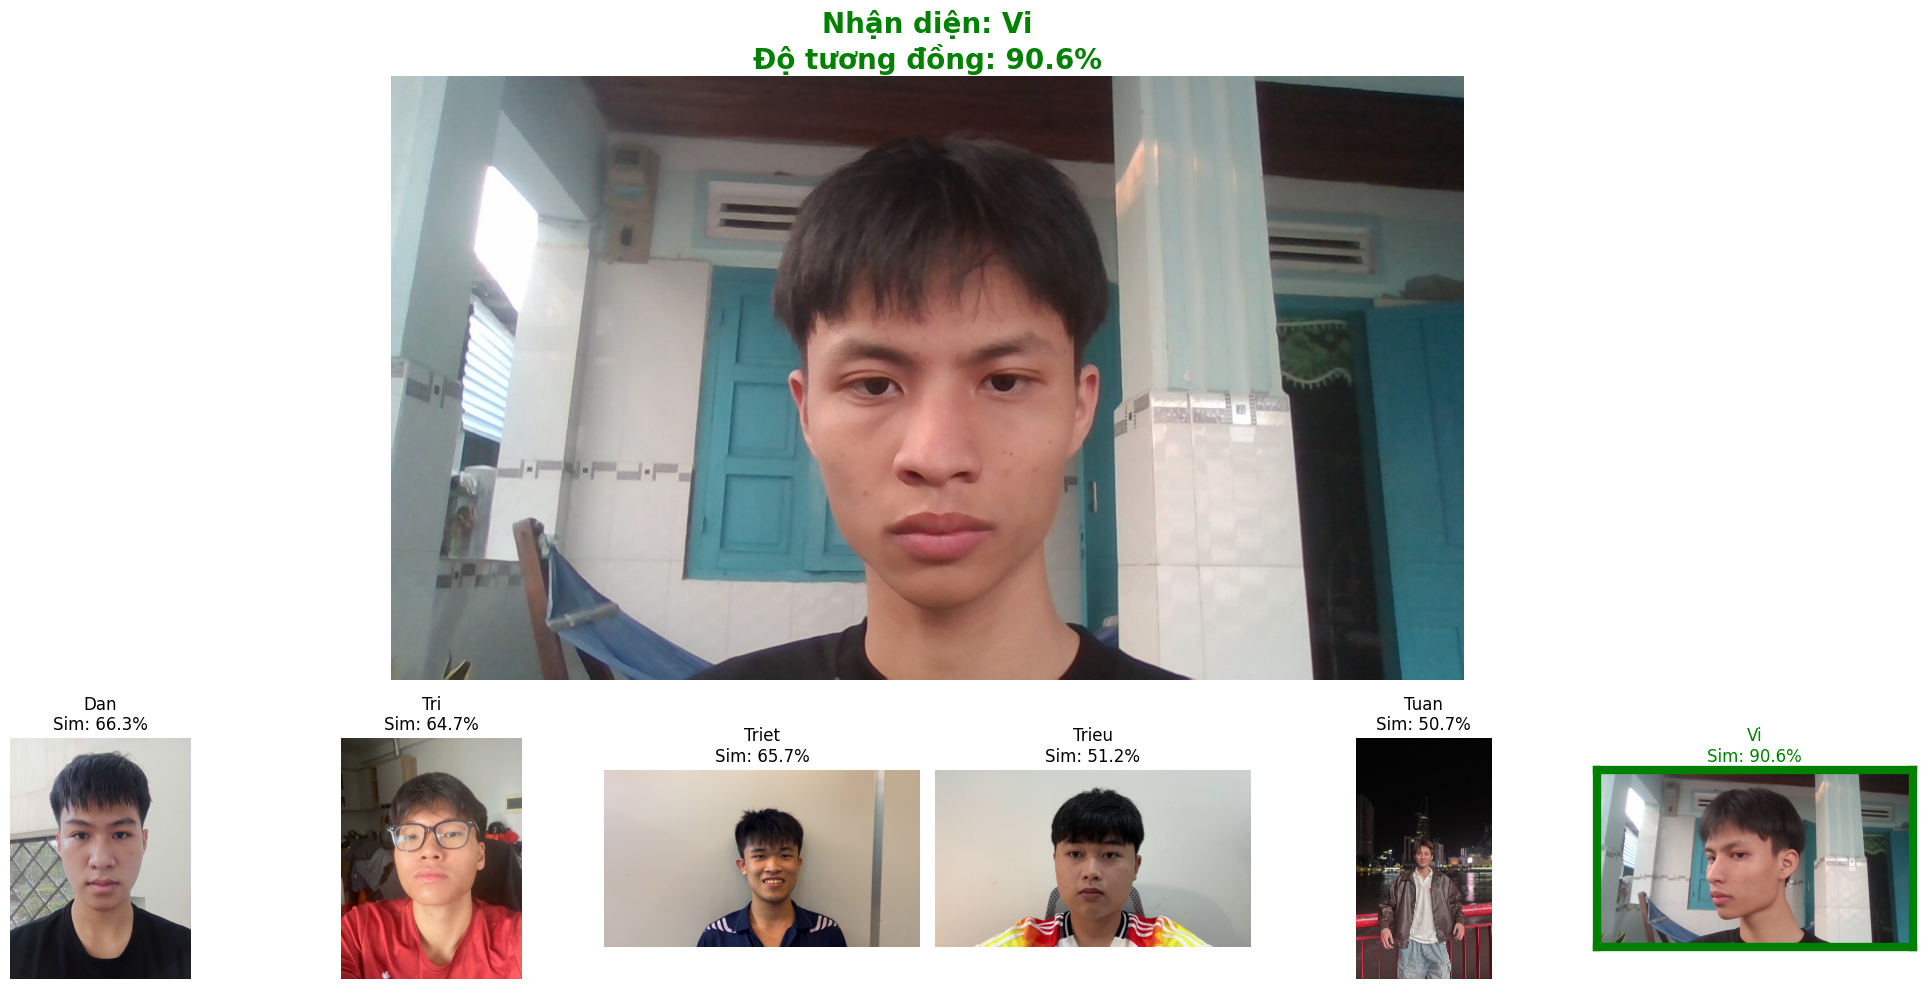

 Đang kiểm tra: photo_5_2026-04-09_17-22-10.jpg

KẾT QUẢ: Triet | SUCCESS
-----------------------------------------------------------------
Tên Database       | Độ tương đồng     
-----------------------------------------------------------------
  Dan              | 57.9              %
  Tri              | 55.5              %
> Triet            | 83.1              %
  Trieu            | 41.4              %
  Tuan             | 48.3              %
  Vi               | 57.4              %



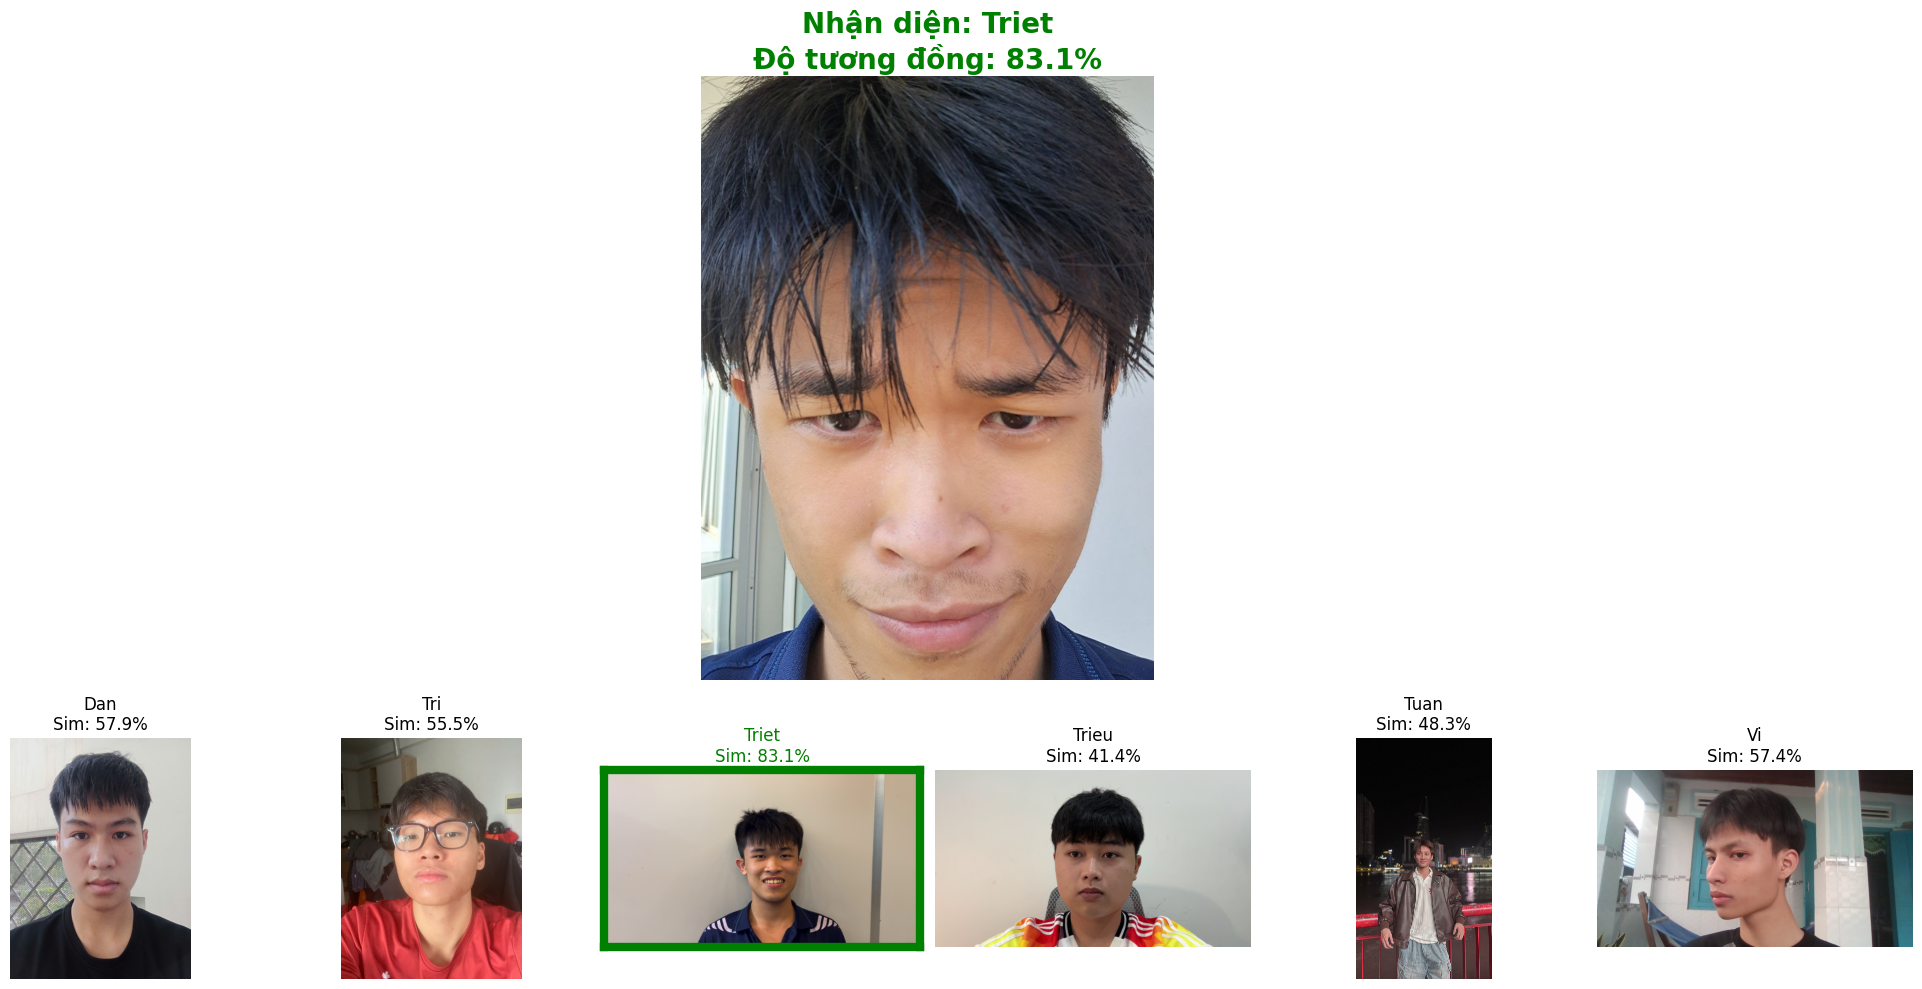

 Đang kiểm tra: photo_14_2026-04-27_16-44-55.jpg

KẾT QUẢ: Triet | SUCCESS
-----------------------------------------------------------------
Tên Database       | Độ tương đồng     
-----------------------------------------------------------------
  Dan              | 64.0              %
  Tri              | 65.0              %
> Triet            | 86.5              %
  Trieu            | 48.2              %
  Tuan             | 49.7              %
  Vi               | 64.9              %



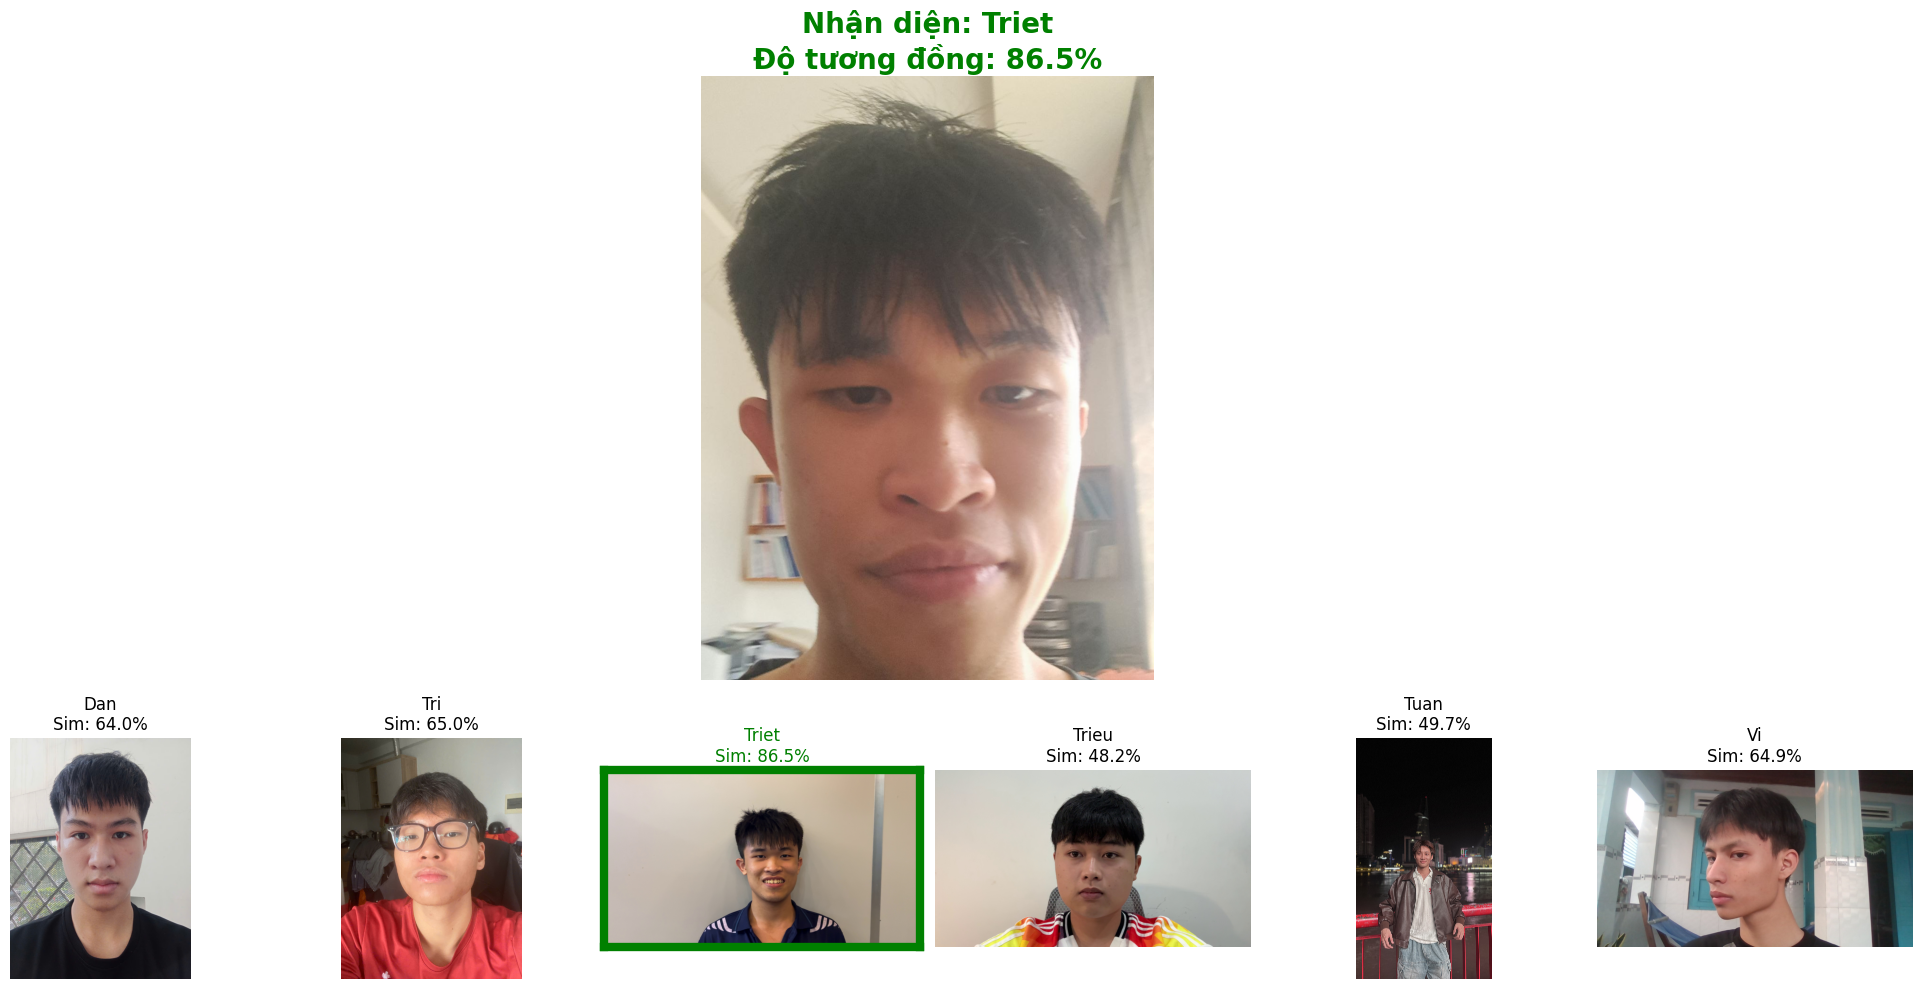

In [37]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
def run_test(test_path, database, threshold, num=3):
    all_imgs = []
    for root, _, files in os.walk(test_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_imgs.append(os.path.join(root, f))

    samples = random.sample(all_imgs, min(num, len(all_imgs)))
    for path in samples:
        print(f" Đang kiểm tra: {os.path.basename(path)}")
        img = load_fix_and_rotate(path)
        if img:
            face = mtcnn(img)
            if face is not None:
                emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()
                plot_recognition_gallery(img, emb, database, threshold)

run_test(TEST_DIR, face_db, OPTIMAL_L2_THRESHOLD)

# Input 1 - Nhận diện qua URL ảnh mạng


 Dán link ảnh mạng vào đây: https://nhaquanly.vn/uploads/images/blog/dangbinh/2023/07/26/x-1690369175.jpg

KẾT QUẢ: Unknown (Người Lạ) | REJECTED (> 0.8500000000000003)
-----------------------------------------------------------------
Tên Database       | Độ tương đồng     
-----------------------------------------------------------------
  Dan              | 1.4               %
  Tri              | 5.3               %
  Triet            | 8.8               %
  Trieu            | 23.7              %
  Tuan             | 20.3              %
  Vi               | 23.4              %



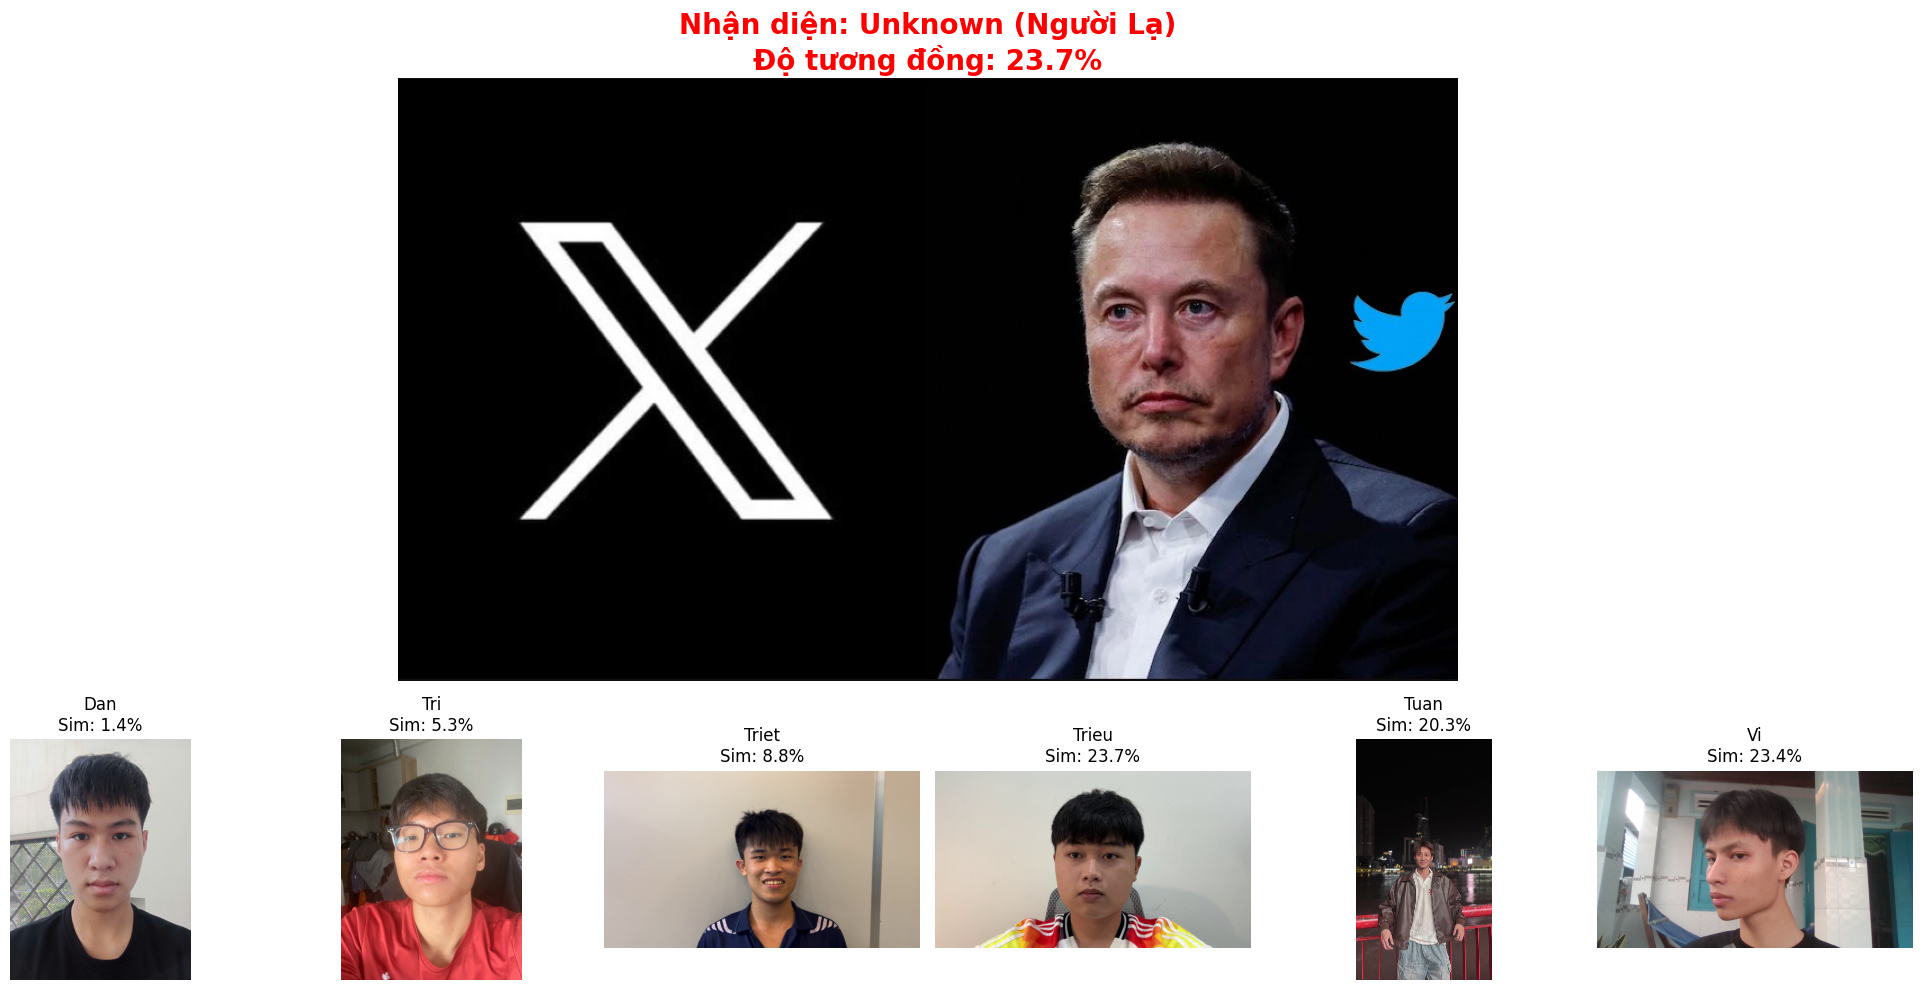

In [38]:
url_input = input(" Dán link ảnh mạng vào đây: ")
if url_input:
    try:
        res = requests.get(url_input, timeout=10)
        img = Image.open(BytesIO(res.content))
        img = ImageOps.exif_transpose(img).convert('RGB')
        face = mtcnn(img)
        if face is not None:
            emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()
            plot_recognition_gallery(img, emb, face_db, OPTIMAL_L2_THRESHOLD)
        else: print(" Không tìm thấy mặt.")
    except Exception as e: print(f" Lỗi: {e}")

# Nhận diện qua Camera trực tiếp

<IPython.core.display.Javascript object>


KẾT QUẢ: Unknown (Người Lạ) | REJECTED (> 0.8500000000000003)
-----------------------------------------------------------------
Tên Database       | Độ tương đồng     
-----------------------------------------------------------------
  Dan              | 47.7              %
  Tri              | 36.7              %
  Triet            | 63.6              %
  Trieu            | 42.2              %
  Tuan             | 28.1              %
  Vi               | 54.3              %



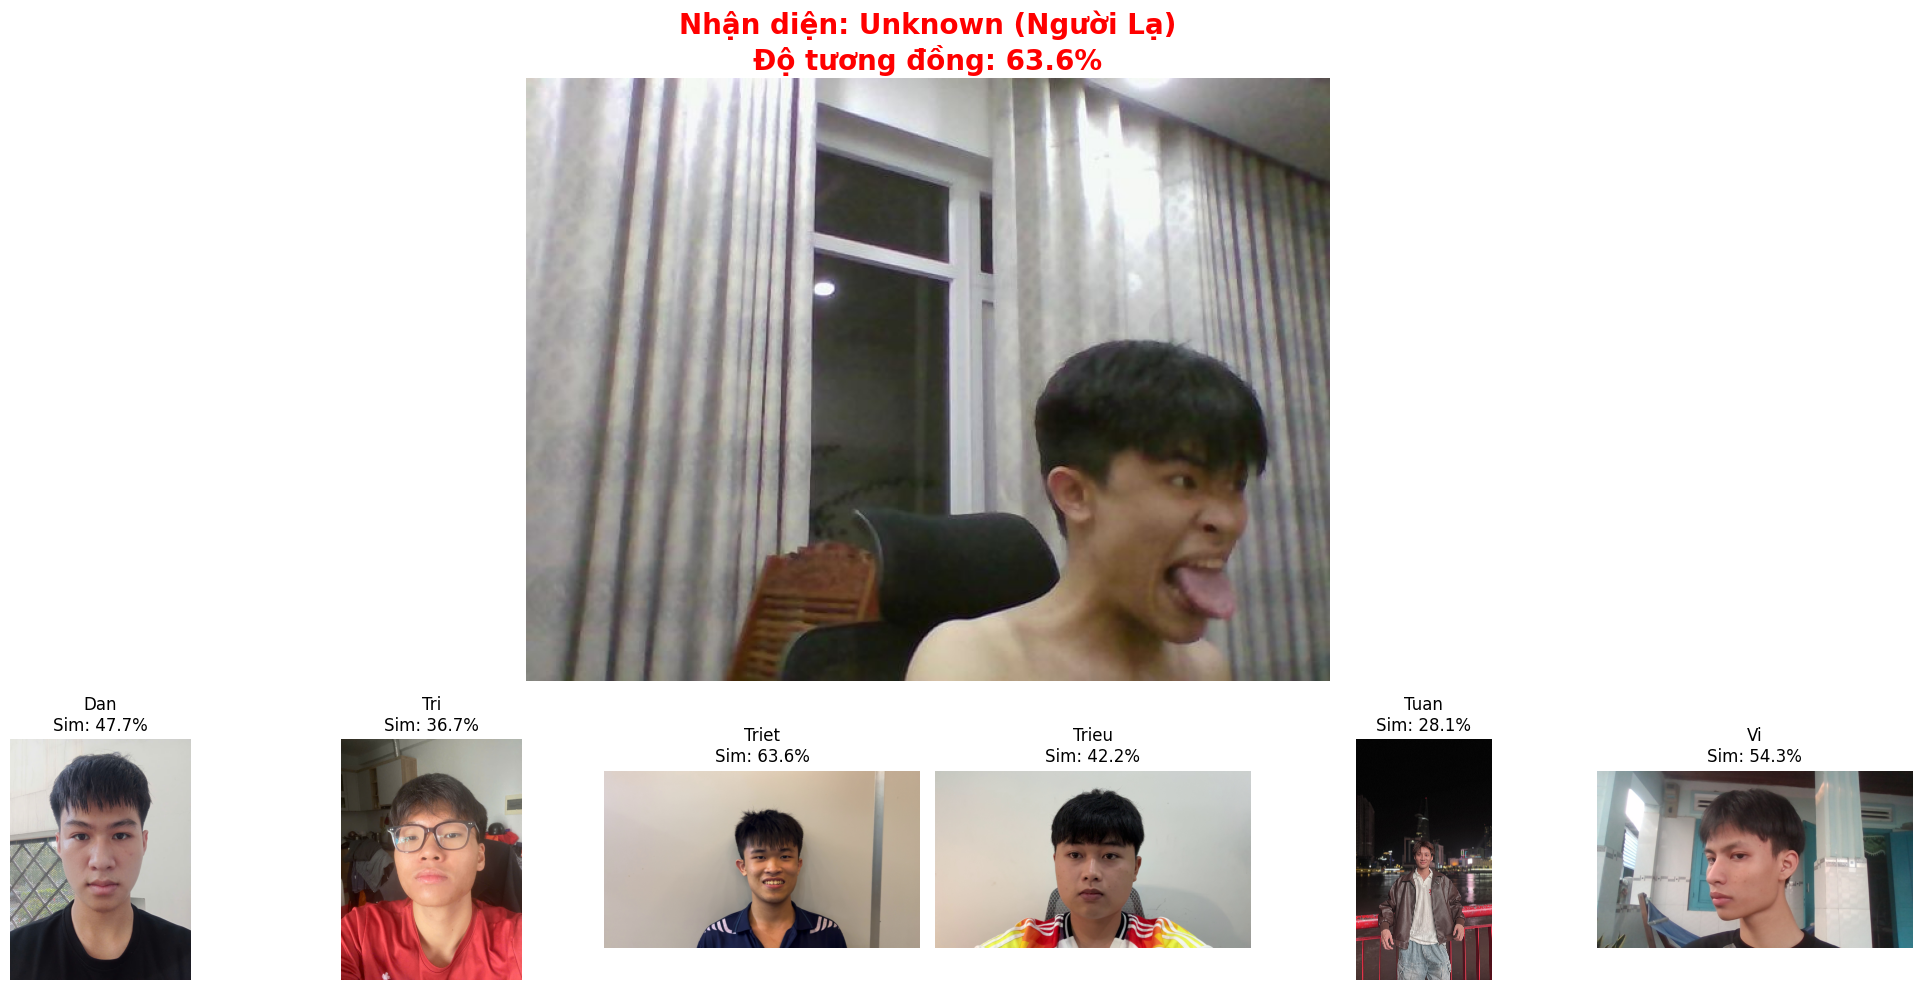

In [39]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg'):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();
      const capture = document.createElement('button');
      capture.textContent = '📸 CHỤP ẢNH';
      div.appendChild(capture);
      await new Promise((resolve) => capture.onclick = resolve);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth; canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto(0.8)')
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f: f.write(binary)
  return filename

try:
    path = take_photo()
    img = load_fix_and_rotate(path)
    face = mtcnn(img)
    if face is not None:
        emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()
        plot_recognition_gallery(img, emb, face_db, OPTIMAL_L2_THRESHOLD)
except Exception as e: print(f" Lỗi Camera: {e}")

# Classification Report

BÁO CÁO PHÂN LOẠI TOÀN DIỆN (Ngưỡng L2: 0.85)

 1. CLASSIFICATION REPORT (Báo cáo Phân loại):

              precision    recall  f1-score   support

         Dan       1.00      1.00      1.00        10
         Tri       1.00      1.00      1.00        10
       Triet       1.00      1.00      1.00        10
       Trieu       1.00      1.00      1.00        10
        Tuan       1.00      1.00      1.00        10
          Vi       1.00      1.00      1.00        10

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


 2. CONFUSION MATRIX :


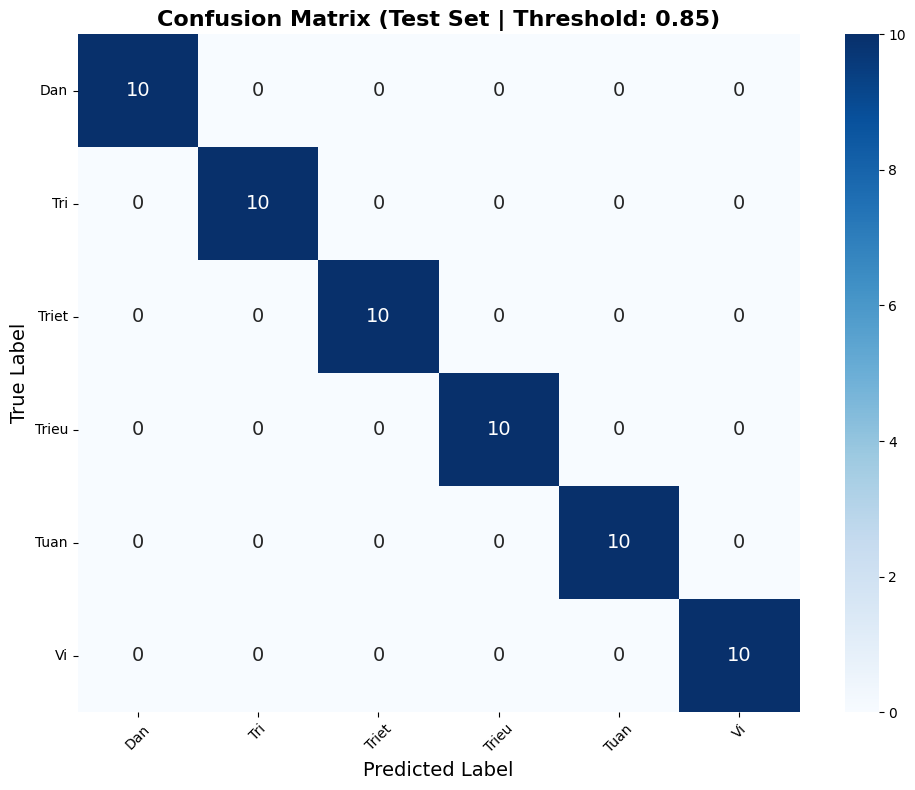

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
import numpy as np

def generate_classification_report(test_path, database, threshold):
    print("="*70)
    print(f"BÁO CÁO PHÂN LOẠI TOÀN DIỆN (Ngưỡng L2: {threshold:.2f})")
    print("="*70)

    y_true = []
    y_pred = []

    folders = sorted([f for f in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, f))])

    for folder in folders:
        folder_path = os.path.join(test_path, folder)
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for img_name in images:
            img_path = os.path.join(folder_path, img_name)
            img = load_fix_and_rotate(img_path)

            if img:
                face = mtcnn(img)
                if face is not None:
                    emb = resnet(face.unsqueeze(0).to(device)).detach().cpu()

                    # So sánh khoảng cách L2
                    dists = {name: torch.dist(emb, db_emb).item() for name, db_emb in database.items()}
                    best_match = min(dists, key=dists.get)
                    min_dist = dists[best_match]

                    # Áp dụng ngưỡng
                    if min_dist <= threshold:
                        prediction = best_match
                    else:
                        prediction = "Unknown" # Lớn hơn ngưỡng thì gán là người lạ
                else:
                    prediction = "Unknown" # Không tìm thấy mặt cũng bị coi là rớt (Unknown)

                y_true.append(folder)
                y_pred.append(prediction)

    if not y_true:
        print("Không có dữ liệu trong tập Test để đánh giá!")
        return

    # --- 1. IN BÁO CÁO PHÂN LOẠI BẰNG TEXT ---
    print("\n 1. CLASSIFICATION REPORT (Báo cáo Phân loại):\n")
    # zero_division=0 để tránh cảnh báo nếu có class bị thiếu
    report = classification_report(y_true, y_pred, zero_division=0)
    print(report)

    # --- 2. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)  ---
    print("\n 2. CONFUSION MATRIX :")

    # Lấy danh sách nhãn (Bao gồm cả Unknown nếu máy có dự đoán ra)
    labels = sorted(list(set(y_true + y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 14})

    plt.title(f'Confusion Matrix (Test Set | Threshold: {threshold:.2f})', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Gọi hàm chạy báo cáo
generate_classification_report(TEST_DIR, face_db, OPTIMAL_L2_THRESHOLD)